<a href="https://colab.research.google.com/github/Janpu-Hou/IoT_Cybersecurity/blob/main/IoT23_AE_LSTM_IDS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Download the IoT-23 dataset
!wget https://mcfp.felk.cvut.cz/publicDatasets/IoT-23-Dataset/iot_23_datasets_small.tar.gz

--2026-08-07 16:00:25--  https://mcfp.felk.cvut.cz/publicDatasets/IoT-23-Dataset/iot_23_datasets_small.tar.gz
Resolving mcfp.felk.cvut.cz (mcfp.felk.cvut.cz)... 147.32.82.194
Connecting to mcfp.felk.cvut.cz (mcfp.felk.cvut.cz)|147.32.82.194|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9373916249 (8.7G) [application/x-gzip]
Saving to: ‘iot_23_datasets_small.tar.gz’

iot_23_datasets_sma 100%[===================>]   8.73G  9.35MB/s    in 17m 17s 

2026-08-07 16:17:43 (8.62 MB/s) - ‘iot_23_datasets_small.tar.gz’ saved [9373916249/9373916249]



In [3]:
# Extract the contents of the tar.gz file
!tar -xzvf iot_23_datasets_small.tar.gz

opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT-Malware-Capture-1-1/bro/conn.log.labeled
opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT-Malware-Capture-17-1/bro/conn.log.labeled
opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT-Malware-Capture-20-1/bro/conn.log.labeled
opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT-Malware-Capture-21-1/bro/conn.log.labeled
opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT-Malware-Capture-3-1/bro/conn.log.labeled
opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT-Malware-Capture-33-1/bro/conn.log.labeled
opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT-Malware-Capture-34-1/bro/conn.log.labeled
opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT-Malware-Capture-35-1/bro/conn.log.labeled
opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT-Malware-Capture-36-1/bro/conn.log.labeled
opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT-Malware-Capture-39-1/bro/conn.log.labeled
opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT-Malware-Ca

The dataset has been downloaded and extracted. You can now explore the contents of the `iot_23_datasets_small` directory.

In [4]:
# List the contents of the extracted directory
!ls -R opt

opt:
Malware-Project

opt/Malware-Project:
BigDataset

opt/Malware-Project/BigDataset:
IoTScenarios

opt/Malware-Project/BigDataset/IoTScenarios:
CTU-Honeypot-Capture-4-1      CTU-IoT-Malware-Capture-39-1
CTU-Honeypot-Capture-5-1      CTU-IoT-Malware-Capture-42-1
CTU-Honeypot-Capture-7-1      CTU-IoT-Malware-Capture-43-1
CTU-IoT-Malware-Capture-1-1   CTU-IoT-Malware-Capture-44-1
CTU-IoT-Malware-Capture-17-1  CTU-IoT-Malware-Capture-48-1
CTU-IoT-Malware-Capture-20-1  CTU-IoT-Malware-Capture-49-1
CTU-IoT-Malware-Capture-21-1  CTU-IoT-Malware-Capture-52-1
CTU-IoT-Malware-Capture-3-1   CTU-IoT-Malware-Capture-60-1
CTU-IoT-Malware-Capture-33-1  CTU-IoT-Malware-Capture-7-1
CTU-IoT-Malware-Capture-34-1  CTU-IoT-Malware-Capture-8-1
CTU-IoT-Malware-Capture-35-1  CTU-IoT-Malware-Capture-9-1
CTU-IoT-Malware-Capture-36-1

opt/Malware-Project/BigDataset/IoTScenarios/CTU-Honeypot-Capture-4-1:
bro

opt/Malware-Project/BigDataset/IoTScenarios/CTU-Honeypot-Capture-4-1/bro:
conn.log.labeled

opt/Malware

In [5]:
# Count the number of files in the extracted dataset structure
!find opt -type f | wc -l

23


In [6]:
# Display the first 5 rows of a sample dataset file
!head -n 5 opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT-Malware-Capture-1-1/bro/conn.log.labeled

#separator \x09
#set_separator	,
#empty_field	(empty)
#unset_field	-
#path	conn


In [7]:
# Get the header line which contains the column names
!grep '^#fields' opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT-Malware-Capture-1-1/bro/conn.log.labeled | cut -f 2-

ts	uid	id.orig_h	id.orig_p	id.resp_h	id.resp_p	proto	service	duration	orig_bytes	resp_bytes	conn_state	local_orig	local_resp	missed_bytes	history	orig_pkts	orig_ip_bytes	resp_pkts	resp_ip_bytes	tunnel_parents   label   detailed-label


In [8]:
# Count the number of data rows in the file (excluding header lines)
!grep -v '^#' opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT-Malware-Capture-1-1/bro/conn.log.labeled | wc -l

1008748


In [9]:
# Import pandas
import pandas as pd

In [12]:
# Define the path to the dataset file
file_path = 'opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT-Malware-Capture-1-1/bro/conn.log.labeled'

# Read the data into a pandas DataFrame
# Skip lines starting with '#' (metadata lines) and read the header from the first non-comment line.
# The separator is tab-delimited.

import re
import io # Import io for StringIO

# First, find the line number of the actual header and read all lines
with open(file_path, 'r') as f:
    lines = f.readlines()

header_line = -1
for i, line in enumerate(lines):
    if line.startswith('#fields'):
        header_line = i
        break

if header_line != -1:
    header_field_line = lines[header_line]
    raw_column_str = header_field_line.replace('#fields\t', '').strip()

    # Use regex to split by tabs or by two or more spaces
    # This handles cases like 'tunnel_parents   label   detailed-label'
    clean_column_names = [col.strip() for col in re.split(r'\t|\s{2,}', raw_column_str) if col.strip()]

    # Filter out comment lines and the header line itself for data reading
    data_lines = [line for i, line in enumerate(lines) if i > header_line and not line.startswith('#')]

    if not data_lines:
        print("No data rows found after header processing. Creating an empty DataFrame.")
        df = pd.DataFrame(columns=clean_column_names) # Create an empty DataFrame with correct columns
    else:
        data_io = io.StringIO("".join(data_lines))

        # Read the data using the cleaned column names
        # Explicitly set sep to a regex to handle both tabs and multiple spaces
        # header=None as we're providing names
        # on_bad_lines='skip' will ignore malformed rows, which might cause DtypeWarning but prevent ValueError
        try:
            df = pd.read_csv(data_io, sep=r'\t|\s{2,}', header=None, names=clean_column_names, on_bad_lines='skip', engine='python')
            print("DataFrame loaded successfully with corrected column names.")
        except Exception as e:
            print(f"Error reading CSV with explicit names: {e}")
            # Fallback: try reading without names to see inferred columns if the above fails
            data_io.seek(0) # Reset stream position
            df = pd.read_csv(data_io, sep=r'\t|\s{2,}', header=None, on_bad_lines='skip', engine='python')
            print(f"Fallback: DataFrame loaded without explicit names. Inferred {df.shape[1]} columns. Expected {len(clean_column_names)}.")

    print("\nDataFrame Head:")
    display(df.head())
    print("\nDataFrame Info:")
    display(df.info())
else:
    print(f"Could not find the header line starting with '#fields' in {file_path}")

DataFrame loaded successfully with corrected column names.

DataFrame Head:


,ts,uid,id.orig_h,id.orig_p,id.resp_h,id.resp_p,proto,service,duration,orig_bytes,...,local_resp,missed_bytes,history,orig_pkts,orig_ip_bytes,resp_pkts,resp_ip_bytes,tunnel_parents,label,detailed-label
0,1.525880e+09,CUmrqr4svHuSXJy5z7,192.168.100.103,51524,65.127.233.163,23,tcp,-,2.999051,0,...,-,0,S,3,180,0,0,(empty),Malicious,PartOfAHorizontalPortScan
1,1.525880e+09,CH98aB3s1kJeq6SFOc,192.168.100.103,56305,63.150.16.171,23,tcp,-,-,-,...,-,0,S,1,60,0,0,(empty),Malicious,PartOfAHorizontalPortScan
2,1.525880e+09,C3GBTkINvXNjVGtN5,192.168.100.103,41101,111.40.23.49,23,tcp,-,-,-,...,-,0,S,1,60,0,0,(empty),Malicious,PartOfAHorizontalPortScan
3,1.525880e+09,CDe43c1PtgynajGI6,192.168.100.103,60905,131.174.215.147,23,tcp,-,2.998796,0,...,-,0,S,3,180,0,0,(empty),Malicious,PartOfAHorizontalPortScan
4,1.525880e+09,CJaDcG3MZzvf1YVYI4,192.168.100.103,44301,91.42.47.63,23,tcp,-,-,-,...,-,0,S,1,60,0,0,(empty),Malicious,PartOfAHorizontalPortScan



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1008748 entries, 0 to 1008747
Data columns (total 23 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   ts              1008748 non-null  float64
 1   uid             1008748 non-null  object 
 2   id.orig_h       1008748 non-null  object 
 3   id.orig_p       1008748 non-null  int64  
 4   id.resp_h       1008748 non-null  object 
 5   id.resp_p       1008748 non-null  int64  
 6   proto           1008748 non-null  object 
 7   service         1008748 non-null  object 
 8   duration        1008748 non-null  object 
 9   orig_bytes      1008748 non-null  object 
 10  resp_bytes      1008748 non-null  object 
 11  conn_state      1008748 non-null  object 
 12  local_orig      1008748 non-null  object 
 13  local_resp      1008748 non-null  object 
 14  missed_bytes    1008748 non-null  int64  
 15  history         1008748 non-null  object 
 16  orig_pkts       100

None

In [13]:
# Calculate the distribution of the 'detailed-label' column
if 'detailed-label' in df.columns:
    label_distribution = df['detailed-label'].value_counts()
    print("\nDistribution of 'detailed-label' column:")
    display(label_distribution)
else:
    print("'detailed-label' column not found in the DataFrame.")


Distribution of 'detailed-label' column:


,count
detailed-label,
PartOfAHorizontalPortScan,539465
-,469275
C&C,8


In [14]:
print("\nSummary statistics for numerical columns:")
display(df.describe())


Summary statistics for numerical columns:


,ts,id.orig_p,id.resp_p,missed_bytes,orig_pkts,orig_ip_bytes,resp_pkts,resp_ip_bytes
count,1.008748e+06,1.008748e+06,1.008748e+06,1008748.0,1.008748e+06,1.008748e+06,1.008748e+06,1.008748e+06
mean,1.526075e+09,4.443684e+04,1.609771e+04,0.0,1.496242e+00,8.114562e+01,1.424647e-01,9.049184e+00
std,1.157431e+05,9.660592e+03,1.956280e+04,0.0,1.741176e+00,9.473090e+01,1.850414e+00,1.196776e+02
min,1.525880e+09,3.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.525975e+09,4.373000e+04,2.300000e+01,0.0,1.000000e+00,4.000000e+01,0.000000e+00,0.000000e+00
50%,1.526071e+09,4.376300e+04,8.080000e+03,0.0,1.000000e+00,6.000000e+01,0.000000e+00,0.000000e+00
75%,1.526174e+09,4.881400e+04,2.818025e+04,0.0,1.000000e+00,6.000000e+01,0.000000e+00,0.000000e+00
max,1.526283e+09,6.539400e+04,6.553500e+04,0.0,6.000000e+01,2.990000e+03,7.500000e+01,9.415000e+03


## Data Preprocessing for LSTM-Autoencoder

Before we can build an LSTM-Autoencoder, we need to preprocess the data. This involves:
1.  Converting data types (`ts` to datetime, `duration`, `orig_bytes`, `resp_bytes` to numeric).
2.  Handling missing values (replacing '-' with NaN and then imputing).
3.  Dropping irrelevant columns (like `uid`).
4.  Encoding categorical features.
5.  Normalizing numerical features.
6.  Filtering the dataset to primarily 'Benign' traffic for training the autoencoder.

In [15]:
import numpy as np

# Convert 'ts' to datetime
df['ts'] = pd.to_datetime(df['ts'], unit='s')

# Convert 'duration', 'orig_bytes', 'resp_bytes' to numeric
# Replace '-' with NaN first, then convert to float
df['duration'] = pd.to_numeric(df['duration'].replace('-', np.nan), errors='coerce')
df['orig_bytes'] = pd.to_numeric(df['orig_bytes'].replace('-', np.nan), errors='coerce')
df['resp_bytes'] = pd.to_numeric(df['resp_bytes'].replace('-', np.nan), errors='coerce')

# Replace '(empty)' string with NaN for consistency in object columns
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].replace('(empty)', np.nan)

# Drop 'uid' column as it's a unique identifier and not useful for modeling
df = df.drop(columns=['uid'])

print("Data types after initial conversions and dropping 'uid':")
display(df.info())

/tmp/ipykernel_3542/376186880.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace('(empty)', np.nan)


Data types after initial conversions and dropping 'uid':
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1008748 entries, 0 to 1008747
Data columns (total 22 columns):
 #   Column          Non-Null Count    Dtype         
---  ------          --------------    -----         
 0   ts              1008748 non-null  datetime64[ns]
 1   id.orig_h       1008748 non-null  object        
 2   id.orig_p       1008748 non-null  int64         
 3   id.resp_h       1008748 non-null  object        
 4   id.resp_p       1008748 non-null  int64         
 5   proto           1008748 non-null  object        
 6   service         1008748 non-null  object        
 7   duration        212448 non-null   float64       
 8   orig_bytes      212448 non-null   float64       
 9   resp_bytes      212448 non-null   float64       
 10  conn_state      1008748 non-null  object        
 11  local_orig      1008748 non-null  object        
 12  local_resp      1008748 non-null  object        
 13  missed_bytes   

None

In [16]:
# Fill NaN values using forward fill then backward fill for numerical columns
# This is a simple imputation strategy, more advanced methods can be used if needed.
for col in ['duration', 'orig_bytes', 'resp_bytes']:
    if col in df.columns:
        df[col] = df[col].fillna(method='ffill').fillna(method='bfill')

# For categorical columns, we can fill with a placeholder like 'missing' or the mode
for col in df.select_dtypes(include='object').columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna('missing') # Fill NaNs in object columns with 'missing'

print("\nMissing values after imputation:")
display(df.isnull().sum())

/tmp/ipykernel_3542/3252539306.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[col] = df[col].fillna(method='ffill').fillna(method='bfill')



Missing values after imputation:


,0
ts,0
id.orig_h,0
id.orig_p,0
id.resp_h,0
id.resp_p,0
proto,0
service,0
duration,0
orig_bytes,0
resp_bytes,0


Now that we've handled the basic data type conversions and missing values, we need to prepare the categorical features. Given the goal of an LSTM-Autoencoder for anomaly detection, we will primarily train on benign traffic. First, let's identify the categorical columns and then decide on an encoding strategy (e.g., one-hot encoding for columns with fewer unique values).

In [17]:
# Identify categorical columns (excluding 'ts', 'label', 'detailed-label')
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Remove target labels if they are in categorical_cols (they will be handled separately)
if 'label' in categorical_cols: categorical_cols.remove('label')
if 'detailed-label' in categorical_cols: categorical_cols.remove('detailed-label')

print("Categorical columns identified:", categorical_cols)

# For demonstration, let's look at the unique values and their counts for some of these columns
for col in categorical_cols:
    if df[col].nunique() < 50: # Limit to columns with fewer unique values for display
        print(f"\nValue counts for '{col}':")
        display(df[col].value_counts())
    else:
        print(f"\nColumn '{col}' has {df[col].nunique()} unique values (too many to display all). Sample: {df[col].unique()[:5]}")

Categorical columns identified: ['id.orig_h', 'id.resp_h', 'proto', 'service', 'conn_state', 'local_orig', 'local_resp', 'history']

Column 'id.orig_h' has 15004 unique values (too many to display all). Sample: ['192.168.100.103' '192.168.100.1' '122.152.1.198' '77.217.131.211'
 '182.38.96.176']

Column 'id.resp_h' has 597107 unique values (too many to display all). Sample: ['65.127.233.163' '63.150.16.171' '111.40.23.49' '131.174.215.147'
 '91.42.47.63']

Value counts for 'proto':


,count
proto,
tcp,583134
udp,408193
icmp,17421



Value counts for 'service':


,count
service,
-,1005507
http,3238
dhcp,1
ssh,1
dns,1



Value counts for 'conn_state':


...


Value counts for 'local_orig':


,count
local_orig,
-,1008748



Value counts for 'local_resp':


,count
local_resp,
-,1008748



Column 'history' has 126 unique values (too many to display all). Sample: ['S' 'Sr' 'D' 'Dd' '-']


In [18]:
# Drop 'tunnel_parents' column as it is entirely null
if 'tunnel_parents' in df.columns:
    df = df.drop(columns=['tunnel_parents'])
    print("Dropped 'tunnel_parents' column due to all null values.")

# One-Hot Encode categorical features
# We'll use get_dummies, but first ensure that columns with too many unique values are handled.
# For 'id.orig_h' and 'id.resp_h' with very high cardinality, one-hot encoding directly is not feasible.
# For this task, we will simplify and exclude them for now, or consider feature hashing if necessary.
# For now, let's proceed with other categorical columns.

# Re-identify categorical columns after dropping 'tunnel_parents' and before one-hot encoding
categorical_cols = df.select_dtypes(include='object').columns.tolist()
if 'label' in categorical_cols: categorical_cols.remove('label')
if 'detailed-label' in categorical_cols: categorical_cols.remove('detailed-label')

# Exclude high cardinality columns 'id.orig_h' and 'id.resp_h' for one-hot encoding for now.
# In a real scenario, these would require advanced feature engineering (e.g., target encoding, embedding, or dimensionality reduction).
low_cardinality_categorical_cols = [col for col in categorical_cols if df[col].nunique() < 50 and col not in ['id.orig_h', 'id.resp_h']]

print(f"\nOne-hot encoding the following categorical columns: {low_cardinality_categorical_cols}")
df = pd.get_dummies(df, columns=low_cardinality_categorical_cols, drop_first=True)

print("\nDataFrame Head after one-hot encoding:")
display(df.head())
print("\nDataFrame Info after one-hot encoding:")
display(df.info())

Dropped 'tunnel_parents' column due to all null values.

One-hot encoding the following categorical columns: ['proto', 'service', 'conn_state', 'local_orig', 'local_resp']

DataFrame Head after one-hot encoding:


,ts,id.orig_h,id.orig_p,id.resp_h,id.resp_p,duration,orig_bytes,resp_bytes,missed_bytes,history,...,conn_state_REJ,conn_state_RSTO,conn_state_RSTOS0,conn_state_RSTR,conn_state_RSTRH,conn_state_S0,conn_state_S1,conn_state_S2,conn_state_SF,conn_state_SH
0,2018-05-09 15:30:31.015810966,192.168.100.103,51524,65.127.233.163,23,2.999051,0.0,0.0,0,S,...,False,False,False,False,False,True,False,False,False,False
1,2018-05-09 15:30:31.025054932,192.168.100.103,56305,63.150.16.171,23,2.999051,0.0,0.0,0,S,...,False,False,False,False,False,True,False,False,False,False
2,2018-05-09 15:30:31.045044899,192.168.100.103,41101,111.40.23.49,23,2.999051,0.0,0.0,0,S,...,False,False,False,False,False,True,False,False,False,False
3,2018-05-09 15:30:32.016239882,192.168.100.103,60905,131.174.215.147,23,2.998796,0.0,0.0,0,S,...,False,False,False,False,False,True,False,False,False,False
4,2018-05-09 15:30:32.024985075,192.168.100.103,44301,91.42.47.63,23,2.998796,0.0,0.0,0,S,...,False,False,False,False,False,True,False,False,False,False



DataFrame Info after one-hot encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1008748 entries, 0 to 1008747
Data columns (total 32 columns):
 #   Column             Non-Null Count    Dtype         
---  ------             --------------    -----         
 0   ts                 1008748 non-null  datetime64[ns]
 1   id.orig_h          1008748 non-null  object        
 2   id.orig_p          1008748 non-null  int64         
 3   id.resp_h          1008748 non-null  object        
 4   id.resp_p          1008748 non-null  int64         
 5   duration           1008748 non-null  float64       
 6   orig_bytes         1008748 non-null  float64       
 7   resp_bytes         1008748 non-null  float64       
 8   missed_bytes       1008748 non-null  int64         
 9   history            1008748 non-null  object        
 10  orig_pkts          1008748 non-null  int64         
 11  orig_ip_bytes      1008748 non-null  int64         
 12  resp_pkts          1008748 non-null  int64  

None

Now that we've encoded categorical features, we need to filter the dataset for training. The LSTM Autoencoder is typically trained on 'normal' or 'benign' data to learn its patterns. Anomalies are then detected as deviations from these learned patterns.

In [35]:
# Filter out 'Benign' traffic for training the autoencoder
# We'll create a training dataset (X_train) consisting only of 'Benign' traffic.

# First, ensure 'detailed-label' column is clean and standardized
df['detailed-label'] = df['detailed-label'].astype(str).str.strip().str.lower()

# Separate benign and malicious traffic
# Assuming '-' in 'detailed-label' represents benign traffic based on value_counts
df_benign = df[df['detailed-label'] == '-'].copy()
df_malicious = df[df['detailed-label'] != '-'].copy()

print(f"Number of benign samples: {len(df_benign)}")
print(f"Number of malicious samples: {len(df_malicious)}")

# Select features for the autoencoder. Exclude 'ts', 'label', and 'detailed-label'.
# Also explicitly exclude high cardinality object columns and 'history' which was not one-hot encoded.
features_to_exclude = ['ts', 'label', 'detailed-label', 'id.orig_h', 'id.resp_h', 'history']

X = df_benign.drop(columns=[col for col in features_to_exclude if col in df_benign.columns], errors='ignore')

# Identify numerical columns for scaling
numerical_cols = X.select_dtypes(include=np.number).columns

print(f"\nFeatures selected for autoencoder training (X shape): {X.shape}")
print(f"Numerical columns for scaling: {list(numerical_cols)}")

Number of benign samples: 469275
Number of malicious samples: 539473

Features selected for autoencoder training (X shape): (469275, 26)
Numerical columns for scaling: ['id.orig_p', 'id.resp_p', 'duration', 'orig_bytes', 'resp_bytes', 'missed_bytes', 'orig_pkts', 'orig_ip_bytes', 'resp_pkts', 'resp_ip_bytes']


Next, we'll normalize the numerical features. This is crucial for neural networks like LSTMs, as it helps prevent features with larger scales from dominating the learning process.

In [43]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Apply scaling only to numerical columns in X
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

# Convert boolean columns to float (0.0 or 1.0) as Keras expects numerical inputs
boolean_cols = X.select_dtypes(include='bool').columns
if not boolean_cols.empty:
    X[boolean_cols] = X[boolean_cols].astype(float)

# Explicitly convert all columns in X to float to ensure no object dtypes remain
X = X.astype(float)

print("\nFirst 5 rows of scaled benign features (X):")
display(X.head())

print("\nDescriptive statistics of scaled benign features (X):")
display(X.describe())


First 5 rows of scaled benign features (X):


,id.orig_p,id.resp_p,duration,orig_bytes,resp_bytes,missed_bytes,orig_pkts,orig_ip_bytes,resp_pkts,resp_ip_bytes,...,conn_state_REJ,conn_state_RSTO,conn_state_RSTOS0,conn_state_RSTR,conn_state_RSTRH,conn_state_S0,conn_state_S1,conn_state_S2,conn_state_SF,conn_state_SH
6,0.523619,0.756237,0.010234,0.0,0.0,0.0,0.057143,0.047458,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
7,0.532749,0.324834,0.010234,0.0,0.0,0.0,0.000000,0.006780,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
17,0.523619,0.756237,0.010234,0.0,0.0,0.0,0.000000,0.006780,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
30,0.523619,0.756237,0.010234,0.0,0.0,0.0,0.000000,0.006780,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
47,0.515086,0.530968,0.010234,0.0,0.0,0.0,0.057143,0.047458,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0



Descriptive statistics of scaled benign features (X):


,id.orig_p,id.resp_p,duration,orig_bytes,resp_bytes,missed_bytes,orig_pkts,orig_ip_bytes,resp_pkts,resp_ip_bytes,...,conn_state_REJ,conn_state_RSTO,conn_state_RSTOS0,conn_state_RSTR,conn_state_RSTRH,conn_state_S0,conn_state_S1,conn_state_S2,conn_state_SF,conn_state_SH
count,469275.000000,469275.000000,469275.000000,469275.000000,469275.000000,469275.0,469275.000000,469275.000000,469275.000000,469275.000000,...,469275.000000,469275.0,469275.000000,469275.000000,469275.000000,469275.000000,469275.000000,469275.000000,469275.000000,469275.000000
mean,0.636248,0.471846,0.011104,0.002384,0.001037,0.0,0.002038,0.002717,0.000588,0.000561,...,0.000912,0.0,0.000401,0.000013,0.000045,0.947408,0.000004,0.000006,0.014073,0.000015
std,0.159774,0.303294,0.015239,0.011845,0.009397,0.0,0.011881,0.010707,0.007060,0.005830,...,0.030186,0.0,0.020011,0.003576,0.006689,0.223217,0.002064,0.002528,0.117791,0.003862
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.669205,0.204776,0.010234,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,0.669205,0.469596,0.010234,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,0.669205,0.735454,0.010235,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,1.000000,1.000000,1.000000,...,1.000000,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Finally, we need to transform our data into sequences suitable for an LSTM. An LSTM processes data sequentially, so we'll convert the DataFrame into a 3D array where each sample is a sequence of observations over time.

In [50]:
# Function to create sequences for LSTM
def create_sequences(data, time_steps):
    Xs = []
    for i in range(len(data) - time_steps + 1):
        Xs.append(data.iloc[i:(i + time_steps)].values)
    # Explicitly cast to float32 to prevent any object dtype issues during Keras training
    return np.array(Xs, dtype=np.float32)

# Define the number of time steps (sequence length)
time_steps = 10 # This is a hyperparameter that might need tuning

# Create sequences from the scaled benign data
X_sequences = create_sequences(X, time_steps)

print(f"\nShape of X_sequences for LSTM: {X_sequences.shape}")
print(f"Dtype of X_sequences: {X_sequences.dtype}")
print("Example of a single sequence:")
print(X_sequences[0])


Shape of X_sequences for LSTM: (469266, 10, 26)
Dtype of X_sequences: float32
Example of a single sequence:
[[0.5236195  0.75623715 0.01023446 0.         0.         0.
  0.05714286 0.04745763 0.         0.         1.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         1.         0.         0.
  0.         0.        ]
 [0.5327492  0.32483405 0.01023446 0.         0.         0.
  0.         0.00677966 0.         0.         1.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         1.         0.         0.
  0.         0.        ]
 [0.5236195  0.75623715 0.01023447 0.         0.         0.
  0.         0.00677966 0.         0.         1.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         1.         0.         0.
  0.         0.        ]
 [0.5236195  0.75623715 0.01023449 0.         0.         0.
  0.         0.00677966 0.         0

## Building and Training the LSTM Autoencoder Model

Now we will define the architecture of our LSTM Autoencoder using Keras. The autoencoder will consist of an encoder part to compress the input sequences into a latent space representation, and a decoder part to reconstruct the original sequences from this representation.

In [51]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
from tensorflow.keras.optimizers import Adam

# Define the input shape (time_steps, number_of_features)
n_features = X_sequences.shape[2]

# Encoder
inputs = Input(shape=(time_steps, n_features))
encoder_lstm = LSTM(units=128, activation='relu', return_sequences=False)(inputs) # Encode to a single vector
latent_vector = Dense(units=64, activation='relu')(encoder_lstm)

# Decoder
# Repeat the latent vector for each time step of the output sequence
decoder_repeat = RepeatVector(time_steps)(latent_vector)
decoder_lstm = LSTM(units=128, activation='relu', return_sequences=True)(decoder_repeat)

# TimeDistributed Dense layer for output reconstruction at each time step
output = TimeDistributed(Dense(units=n_features, activation='linear'))(decoder_lstm)

# Combine encoder and decoder into an autoencoder model
model = Model(inputs=inputs, outputs=output)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

print("LSTM Autoencoder Model Summary:")
model.summary()

LSTM Autoencoder Model Summary:


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 10, 26)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 128)            │        79,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_3 (RepeatVector)  │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 10, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 10, 26)         │         3,354 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 189,786 (741.35 KB)

 Trainable params: 189,786 (741.35 KB)

 Non-trainable params: 0 (0.00 B)

With the model defined, let's train it on our `X_sequences` data. The goal is for the autoencoder to learn the normal patterns of the benign traffic, so we will train it to reconstruct its own input. The reconstruction error will then be used to identify anomalies.

In [54]:
import tensorflow as tf

# Convert X_sequences to a TensorFlow tensor with float32 dtype
X_sequences_tf = tf.constant(X_sequences, dtype=tf.float32)

# Train the model
# We use X_sequences_tf as both input and target for the autoencoder
history = model.fit(
    X_sequences_tf,
    X_sequences_tf,
    epochs=50, # Number of training epochs, can be tuned
    batch_size=64, # Batch size, can be tuned
    validation_split=0.1, # Use a portion of the training data for validation
    shuffle=False # For time series, it's often better not to shuffle
)

print("\nModel training complete.")

Epoch 1/50
6600/6600 ━━━━━━━━━━━━━━━━━━━━ 316s 48ms/step - loss: 3.0620e-05 - val_loss: 6.9184e-06
Epoch 2/50
6600/6600 ━━━━━━━━━━━━━━━━━━━━ 308s 47ms/step - loss: 3.0952e-05 - val_loss: 6.2601e-06
Epoch 3/50
6600/6600 ━━━━━━━━━━━━━━━━━━━━ 334s 48ms/step - loss: 3.0709e-05 - val_loss: 6.4149e-06
Epoch 4/50
6600/6600 ━━━━━━━━━━━━━━━━━━━━ 305s 46ms/step - loss: 2.7711e-05 - val_loss: 6.1891e-06
Epoch 5/50
6600/6600 ━━━━━━━━━━━━━━━━━━━━ 323s 46ms/step - loss: 2.8694e-05 - val_loss: 5.5885e-06
Epoch 6/50
6600/6600 ━━━━━━━━━━━━━━━━━━━━ 326s 47ms/step - loss: 3.1244e-05 - val_loss: 6.1774e-06
Epoch 7/50
6600/6600 ━━━━━━━━━━━━━━━━━━━━ 304s 46ms/step - loss: 3.3938e-05 - val_loss: 5.9394e-06
Epoch 8/50
6600/6600 ━━━━━━━━━━━━━━━━━━━━ 304s 46ms/step - loss: 2.7550e-05 - val_loss: 5.5307e-06
Epoch 9/50
6600/6600 ━━━━━━━━━━━━━━━━━━━━ 305s 46ms/step - loss: 2.5883e-05 - val_loss: 5.1967e-06
Epoch 10/50
6600/6600 ━━━━━━━━━━━━━━━━━━━━ 304s 46ms/step - loss: 2.9812e-05 - val_loss: 5.5781e-06
Epoch 11/

Let's visualize the training and validation loss over epochs to ensure the model is learning effectively and to check for overfitting.

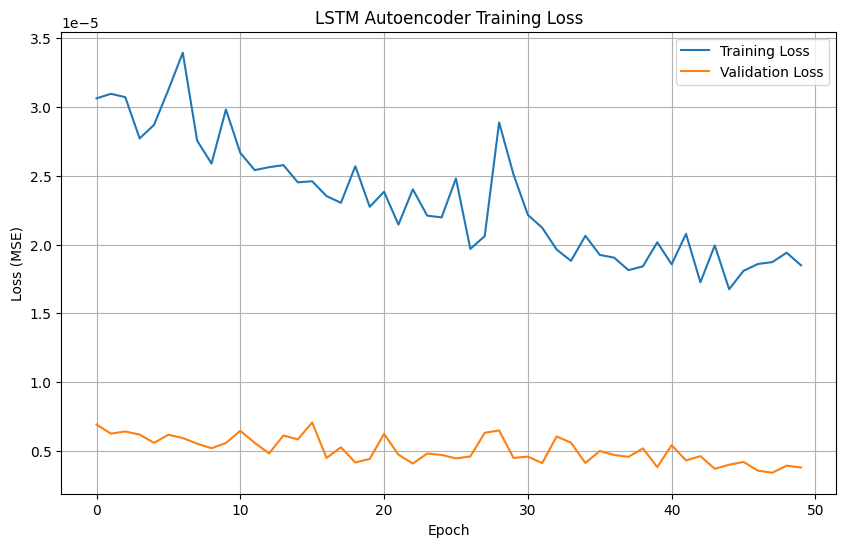

Loss plot displayed.


In [55]:
import matplotlib.pyplot as plt

# Plot the training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Autoencoder Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

print("Loss plot displayed.")

## Anomaly Detection - Calculating Reconstruction Error and Setting Threshold

To detect anomalies, we'll use the trained autoencoder to reconstruct the benign training data (`X_sequences`). The reconstruction error (e.g., Mean Squared Error) between the original and reconstructed sequences will serve as our anomaly score. We'll then set a threshold based on the distribution of these errors from the benign data. Any data point whose reconstruction error exceeds this threshold will be flagged as anomalous.

14665/14665 ━━━━━━━━━━━━━━━━━━━━ 169s 11ms/step


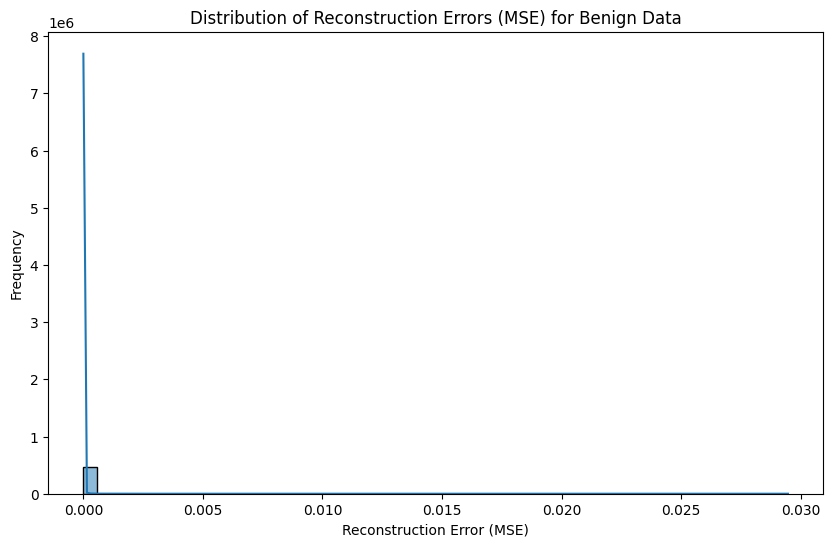


Reconstruction errors calculated for benign data and distribution plotted.


In [56]:
# Get the reconstruction errors for the training data (benign traffic)
X_pred = model.predict(X_sequences_tf) # Use the TensorFlow tensor for prediction

# Calculate the Mean Squared Error (MSE) for each sequence
mse = np.mean(np.power(X_sequences_tf - X_pred, 2), axis=(1, 2))

# Plot the distribution of reconstruction errors for benign data
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(mse, bins=50, kde=True)
plt.title('Distribution of Reconstruction Errors (MSE) for Benign Data')
plt.xlabel('Reconstruction Error (MSE)')
plt.ylabel('Frequency')
plt.show()

print("\nReconstruction errors calculated for benign data and distribution plotted.")

Based on the distribution of reconstruction errors for benign data, we can set an appropriate threshold. A common approach is to use a percentile (e.g., 95th or 99th percentile) of the errors, or a fixed multiple of the standard deviation from the mean.

Calculated anomaly threshold (95th percentile of benign MSE): 0.0000


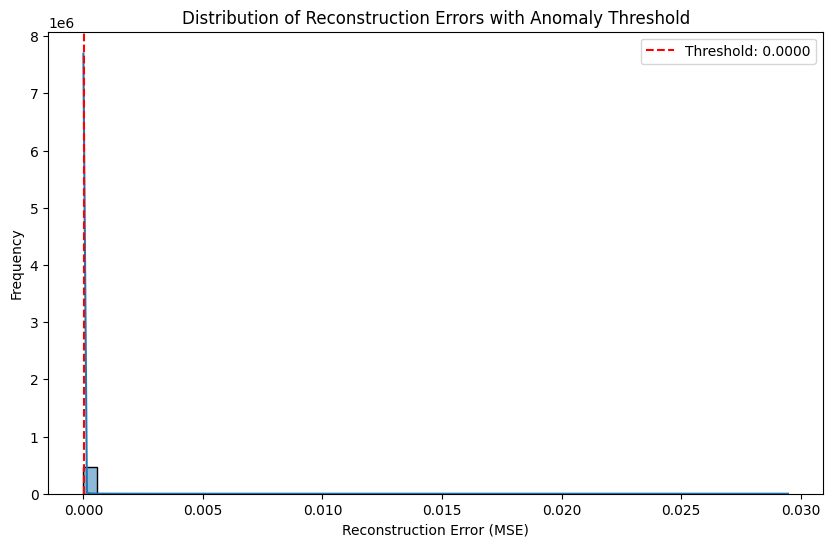

Anomaly threshold set and visualized.


In [57]:
# Set an anomaly threshold
# For example, using the 95th percentile of the MSE of the benign data
threshold = np.percentile(mse, 95) # This can be tuned
print(f"Calculated anomaly threshold (95th percentile of benign MSE): {threshold:.4f}")

# Plot the threshold on the error distribution
plt.figure(figsize=(10, 6))
sns.histplot(mse, bins=50, kde=True)
plt.axvline(x=threshold, color='r', linestyle='--', label=f'Threshold: {threshold:.4f}')
plt.title('Distribution of Reconstruction Errors with Anomaly Threshold')
plt.xlabel('Reconstruction Error (MSE)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

print("Anomaly threshold set and visualized.")

In [58]:
import os

# Define the path to save the model
model_save_path = 'lstm_autoencoder_model.keras'

# Save the model
model.save(model_save_path)

print(f"LSTM Autoencoder model saved successfully to {model_save_path}")

# Verify the model exists
if os.path.exists(model_save_path):
    print("Model file confirmed to exist.")
else:
    print("Error: Model file not found after saving.")

LSTM Autoencoder model saved successfully to lstm_autoencoder_model.keras
Model file confirmed to exist.


The LSTM Autoencoder model has been saved. You can load it later using `tf.keras.models.load_model('lstm_autoencoder_model.keras')`.

In [59]:
import os

model_save_path = 'lstm_autoencoder_model.keras'

# Get the file size in bytes
file_size_bytes = os.path.getsize(model_save_path)

# Convert to megabytes
file_size_mb = file_size_bytes / (1024 * 1024)

print(f"The size of the saved model '{model_save_path}' is {file_size_mb:.2f} MB.")

The size of the saved model 'lstm_autoencoder_model.keras' is 2.21 MB.


### Comparing Benign vs. Malicious Reconstruction Errors

Now, let's process the malicious traffic through our trained autoencoder to see how its reconstruction errors compare to the benign traffic errors. This will help us visually evaluate the effectiveness of our anomaly threshold.

In [60]:
import tensorflow as tf

# Ensure training_feature_columns is available from the training phase
# (It was inferred from 'X' in the previous guide, assuming 'X' was still in memory)
if 'X' in globals():
    training_feature_columns = X.columns.tolist()
else:
    raise ValueError("The 'X' DataFrame from training is not available. Cannot align features for malicious data.")

# Prepare malicious data using the same preprocessing steps and scaler as benign data
# Make a copy to avoid modifying the original df_malicious
X_malicious_preprocessed = df_malicious.copy()

# 1. Convert 'ts' to datetime
X_malicious_preprocessed['ts'] = pd.to_datetime(X_malicious_preprocessed['ts'], unit='s')

# 2. Convert 'duration', 'orig_bytes', 'resp_bytes' to numeric, replacing '-' with NaN
X_malicious_preprocessed['duration'] = pd.to_numeric(X_malicious_preprocessed['duration'].replace('-', np.nan), errors='coerce')
X_malicious_preprocessed['orig_bytes'] = pd.to_numeric(X_malicious_preprocessed['orig_bytes'].replace('-', np.nan), errors='coerce')
X_malicious_preprocessed['resp_bytes'] = pd.to_numeric(X_malicious_preprocessed['resp_bytes'].replace('-', np.nan), errors='coerce')

# 3. Replace '(empty)' string with NaN for consistency in object columns
for col in X_malicious_preprocessed.select_dtypes(include='object').columns:
    # Check if '(empty)' actually exists before replacing to avoid unnecessary warnings
    if '(empty)' in X_malicious_preprocessed[col].unique():
        X_malicious_preprocessed[col] = X_malicious_preprocessed[col].replace('(empty)', np.nan)

# 4. Drop 'uid' column
if 'uid' in X_malicious_preprocessed.columns:
    X_malicious_preprocessed = X_malicious_preprocessed.drop(columns=['uid'])

# 5. Handle missing values (ffill then bfill for numeric, 'missing' for object)
# Numerical columns to impute
for col in ['duration', 'orig_bytes', 'resp_bytes', 'missed_bytes', 'orig_pkts', 'orig_ip_bytes', 'resp_pkts', 'resp_ip_bytes']:
    if col in X_malicious_preprocessed.columns:
        X_malicious_preprocessed[col] = X_malicious_preprocessed[col].fillna(method='ffill').fillna(method='bfill')

# Object columns to impute
for col in X_malicious_preprocessed.select_dtypes(include='object').columns:
    if X_malicious_preprocessed[col].isnull().any():
        X_malicious_preprocessed[col] = X_malicious_preprocessed[col].fillna('missing')

# 6. Drop 'tunnel_parents' column if it's all null (or based on training decision)
if 'tunnel_parents' in X_malicious_preprocessed.columns and X_malicious_preprocessed['tunnel_parents'].isnull().all():
    X_malicious_preprocessed = X_malicious_preprocessed.drop(columns=['tunnel_parents'])

# 7. One-Hot Encode categorical features
# Use the same list of low cardinality categorical columns as during training
low_cardinality_categorical_cols_trained = ['proto', 'service', 'conn_state', 'local_orig', 'local_resp'] # FROM TRAINING

cols_to_onehot_encode_in_malicious_df = [col for col in low_cardinality_categorical_cols_trained if col in X_malicious_preprocessed.columns]

X_malicious_preprocessed = pd.get_dummies(X_malicious_preprocessed, columns=cols_to_onehot_encode_in_malicious_df, drop_first=True)

# 8. Drop high-cardinality and other excluded features
features_to_drop_post_processing = ['ts', 'label', 'detailed-label', 'id.orig_h', 'id.resp_h', 'history'] # Add any other columns excluded during training

for col in features_to_drop_post_processing:
    if col in X_malicious_preprocessed.columns:
        X_malicious_preprocessed = X_malicious_preprocessed.drop(columns=[col])

# Align columns with training data features
for col in training_feature_columns:
    if col not in X_malicious_preprocessed.columns:
        X_malicious_preprocessed[col] = 0.0 # Add missing columns with 0.0

# Ensure the order of columns is the same as in training_feature_columns
X_malicious_preprocessed = X_malicious_preprocessed[training_feature_columns]

# 9. Apply MinMaxScaler (using the *fitted* scaler from training)
if 'scaler' not in globals():
    raise ValueError("The 'scaler' object from training is not available. Cannot scale malicious data.")

numerical_cols_malicious = X_malicious_preprocessed.select_dtypes(include=np.number).columns
X_malicious_preprocessed[numerical_cols_malicious] = scaler.transform(X_malicious_preprocessed[numerical_cols_malicious])

# 10. Convert boolean columns to float
boolean_cols_malicious = X_malicious_preprocessed.select_dtypes(include='bool').columns
if not boolean_cols_malicious.empty:
    X_malicious_preprocessed[boolean_cols_malicious] = X_malicious_preprocessed[boolean_cols_malicious].astype(float)

# 11. Explicitly convert all columns to float
X_malicious_preprocessed = X_malicious_preprocessed.astype(float)

# 12. Create sequences for LSTM input
# `time_steps` must be the same as used for benign data
X_malicious_sequences = create_sequences(X_malicious_preprocessed, time_steps)

# Convert to TensorFlow tensor
X_malicious_sequences_tf = tf.constant(X_malicious_sequences, dtype=tf.float32)

print(f"\nShape of X_malicious_sequences for LSTM: {X_malicious_sequences.shape}")

# Load the trained model (if not already loaded)
if 'model' not in globals():
    model_path = 'lstm_autoencoder_model.keras'
    model = tf.keras.models.load_model(model_path)

# Predict reconstruction for malicious sequences
X_malicious_pred = model.predict(X_malicious_sequences_tf)

# Calculate Mean Squared Error (MSE) for each malicious sequence
mse_malicious = np.mean(np.power(X_malicious_sequences_tf - X_malicious_pred, 2), axis=(1, 2))

print("Malicious reconstruction errors calculated.")

/tmp/ipykernel_3542/1796643569.py:36: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X_malicious_preprocessed[col] = X_malicious_preprocessed[col].fillna(method='ffill').fillna(method='bfill')



Shape of X_malicious_sequences for LSTM: (539464, 10, 26)
16859/16859 ━━━━━━━━━━━━━━━━━━━━ 191s 11ms/step
Malicious reconstruction errors calculated.


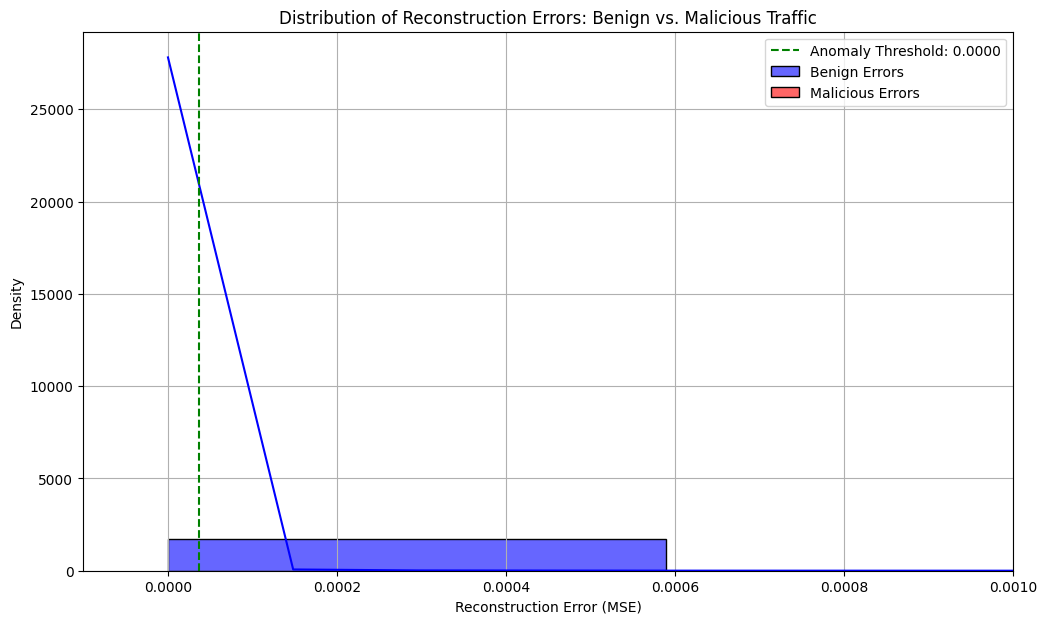

Comparison plot displayed.


In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the distributions of benign and malicious reconstruction errors
plt.figure(figsize=(12, 7))
sns.histplot(mse, bins=50, kde=True, color='blue', label='Benign Errors', stat='density', alpha=0.6)
sns.histplot(mse_malicious, bins=50, kde=True, color='red', label='Malicious Errors', stat='density', alpha=0.6)

# Add the anomaly threshold
if 'threshold' in globals():
    plt.axvline(x=threshold, color='green', linestyle='--', label=f'Anomaly Threshold: {threshold:.4f}')
else:
    print("Warning: 'threshold' variable not found. Cannot plot anomaly threshold.")

plt.title('Distribution of Reconstruction Errors: Benign vs. Malicious Traffic')
plt.xlabel('Reconstruction Error (MSE)')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.xlim([-0.0001, 0.001]) # Adjust x-axis limits for better visualization if needed
plt.show()

print("Comparison plot displayed.")

# How to Prepare PCAP Flow Data for LSTM Autoencoder (Using Zeek)

This guide outlines the steps to take raw PCAP (Packet Capture) files, process them with Zeek (formerly Bro), transform the generated network logs into a compatible format, and then use your trained LSTM Autoencoder model to detect anomalies.

## 1. Convert PCAP to Zeek Logs

Zeek is a powerful network analysis framework that can extract high-level semantic information from network traffic (PCAP files) and write it to structured log files (e.g., `conn.log`, `http.log`, etc.). For our intrusion detection system, the `conn.log` is particularly relevant as it details connection-level information.

### Prerequisites:
*   **Zeek Installation:** Ensure Zeek is installed on your system. Refer to the [official Zeek documentation](https://docs.zeek.org/en/master/install/index.html) for installation instructions.
*   **PCAP File:** Have your incoming PCAP flow file ready (e.g., `incoming_traffic.pcap`).

### Steps:
1.  **Process PCAP with Zeek:**
    Open your terminal or command prompt and run Zeek against your PCAP file. By default, Zeek will generate various log files in the current directory.

    ```bash
    zeek -r incoming_traffic.pcap
    ```

    This command will generate files like `conn.log`, `http.log`, `dns.log`, etc. For our model, we primarily focus on `conn.log`.

2.  **Locate `conn.log`:**
    The `conn.log` file will be created in the directory where you ran the command. This file contains detailed connection records, similar to the `conn.log.labeled` we used for training, but without the specific 'label' and 'detailed-label' columns (as it's raw, unlabelled traffic).

## 2. Load Zeek `conn.log` into a Pandas DataFrame

We need to load the generated `conn.log` into a pandas DataFrame and parse it correctly, similar to how we handled the initial dataset.

```python
import pandas as pd
import numpy as np
import re
import io

new_log_file_path = 'conn.log' # Adjust this path if your conn.log is elsewhere

# --- Step 1: Read the Zeek log file and extract header/data ---
with open(new_log_file_path, 'r') as f:
    lines = f.readlines()

header_line_idx = -1
for i, line in enumerate(lines):
    if line.startswith('#fields'):
        header_line_idx = i
        break

if header_line_idx == -1:
    raise ValueError("Could not find '#fields' line in conn.log. Please ensure it's a valid Zeek log.")

raw_column_str = lines[header_line_idx].replace('#fields\t', '').strip()
# Use regex to split by tabs or by two or more spaces for robust column parsing
new_column_names = [col.strip() for col in re.split(r'\t|\s{2,}', raw_column_str) if col.strip()]

data_lines = [line for i, line in enumerate(lines) if i > header_line_idx and not line.startswith('#')]

if not data_lines:
    print("No data rows found in conn.log. Creating an empty DataFrame.")
    new_df = pd.DataFrame(columns=new_column_names)
else:
    data_io = io.StringIO("".join(data_lines))
    try:
        new_df = pd.read_csv(data_io, sep=r'\t|\s{2,}', header=None, names=new_column_names, on_bad_lines='skip', engine='python')
        print("New traffic DataFrame loaded successfully.")
    except Exception as e:
        print(f"Error reading new traffic CSV: {e}")
        print("Attempting to read without explicit names (may have column mismatch).")
        data_io.seek(0)
        new_df = pd.read_csv(data_io, sep=r'\t|\s{2,}', header=None, on_bad_lines='skip', engine='python')
        new_df.columns = new_column_names[:new_df.shape[1]] # Assign names up to the number of columns read

print("\nHead of new traffic DataFrame:")
display(new_df.head())
print("\nInfo of new traffic DataFrame:")
display(new_df.info())
```

## 3. Preprocessing for LSTM Autoencoder Input

**CRITICAL:** It is paramount to apply the *exact same preprocessing steps* and use the *same fitted scalers and one-hot encoders* that were used during the model's training phase. Any deviation can lead to incorrect predictions.

Make sure you have access to the `scaler` object (a `MinMaxScaler` instance) that was fitted on your training data (`df_benign`) and the `create_sequences` function.

```python
# --- Define the create_sequences function (if not already defined) ---
def create_sequences(data, time_steps):
    Xs = []
    for i in range(len(data) - time_steps + 1):
        Xs.append(data.iloc[i:(i + time_steps)].values)
    return np.array(Xs, dtype=np.float32)

# --- Apply preprocessing steps to the new_df ---

# 1. Convert 'ts' to datetime
new_df['ts'] = pd.to_datetime(new_df['ts'], unit='s')

# 2. Convert 'duration', 'orig_bytes', 'resp_bytes' to numeric, replacing '-' with NaN
new_df['duration'] = pd.to_numeric(new_df['duration'].replace('-', np.nan), errors='coerce')
new_df['orig_bytes'] = pd.to_numeric(new_df['orig_bytes'].replace('-', np.nan), errors='coerce')
new_df['resp_bytes'] = pd.to_numeric(new_df['resp_bytes'].replace('-', np.nan), errors='coerce')

# 3. Replace '(empty)' string with NaN for consistency in object columns
for col in new_df.select_dtypes(include='object').columns:
    if '(empty)' in new_df[col].unique(): # Check if '(empty)' actually exists before replacing
        new_df[col] = new_df[col].replace('(empty)', np.nan)

# 4. Drop 'uid' column
if 'uid' in new_df.columns:
    new_df = new_df.drop(columns=['uid'])

# 5. Handle missing values (ffill then bfill for numeric, 'missing' for object)
# Note: This is simplified. In a real system, you might want more sophisticated imputation
for col in ['duration', 'orig_bytes', 'resp_bytes', 'missed_bytes', 'orig_pkts', 'orig_ip_bytes', 'resp_pkts', 'resp_ip_bytes']:
    if col in new_df.columns:
        new_df[col] = new_df[col].fillna(method='ffill').fillna(method='bfill')

for col in new_df.select_dtypes(include='object').columns:
    if new_df[col].isnull().any():
        new_df[col] = new_df[col].fillna('missing')

# 6. Drop 'tunnel_parents' column if it's all null (or based on training decision)
if 'tunnel_parents' in new_df.columns and new_df['tunnel_parents'].isnull().all():
    new_df = new_df.drop(columns=['tunnel_parents'])

# 7. One-Hot Encode categorical features
# Use the same low_cardinality_categorical_cols identified during training.
# If new categories appear, they will be handled by get_dummies creating new columns.
# Make sure these columns are aligned with the training data's one-hot encoded columns.

# Re-create a list of columns that were one-hot encoded during training.
# This list should exactly match 'low_cardinality_categorical_cols' from your training phase.
# Example (adjust based on your actual training columns):
low_cardinality_categorical_cols_trained = ['proto', 'service', 'conn_state', 'local_orig', 'local_resp'] # FROM TRAINING

# Identify which of these are still in new_df (some might have been dropped or not exist)
cols_to_onehot_encode_in_new_df = [col for col in low_cardinality_categorical_cols_trained if col in new_df.columns]

new_df = pd.get_dummies(new_df, columns=cols_to_onehot_encode_in_new_df, drop_first=True)

# 8. Drop high-cardinality and other excluded features
# This list should match 'features_to_exclude' from your training, minus 'label'/'detailed-label'
# and ensuring 'ts' and 'uid' are already gone.
features_to_drop_post_processing = ['ts', 'id.orig_h', 'id.resp_h', 'history'] # Add any other columns excluded during training

# Drop only if they exist in the current DataFrame
for col in features_to_drop_post_processing:
    if col in new_df.columns:
        new_df = new_df.drop(columns=[col])

# Ensure all columns match those used for training. Add missing dummy columns with 0.
# This is crucial for consistent input shape.
# You need the list of final columns from your training X (excluding 'label' and 'detailed-label')
# Let's assume you have a list called `final_training_features`

# A crucial step: align new_df columns with the features the model was trained on.
# You need to have `X.columns` (the columns of your `X` DataFrame *after* all preprocessing and scaling in the training phase) available.
# For example, let's assume `training_feature_columns` holds the list of column names used in your `X` DataFrame during training.
# Placeholder for the actual feature columns from your training data:
# training_feature_columns = [...] # You need to get this from your notebook's state or save it.

# For this example, we'll try to infer based on existing state, but a robust solution would save and load this list.
# Infer the `training_feature_columns` from `X` (if `X` is still in memory from training)
if 'X' in globals(): # Check if X DataFrame from training is available
    training_feature_columns = X.columns.tolist()
else:
    raise ValueError("The 'X' DataFrame from training is not available. Cannot align features. Please ensure 'X' is saved or re-run training preprocessing.")

# Add missing columns to new_df with value 0 (for new categorical levels not seen in training)
for col in training_feature_columns:
    if col not in new_df.columns:
        new_df[col] = 0.0 # Use float for consistency

# Remove extra columns from new_df that were not in training_feature_columns
new_df = new_df[training_feature_columns]


# 9. Apply MinMaxScaler (using the *fitted* scaler from training)
# The `scaler` object MUST be the one fitted on `df_benign` during training.
if 'scaler' not in globals():
    raise ValueError("The 'scaler' object from training is not available. Cannot scale new data. Please ensure 'scaler' is saved or re-run training preprocessing.")

numerical_cols_trained = new_df.select_dtypes(include=np.number).columns # numerical columns after alignment
new_df[numerical_cols_trained] = scaler.transform(new_df[numerical_cols_trained])

# 10. Convert boolean columns to float (if any new ones were created by one-hot encoding)
boolean_cols_new = new_df.select_dtypes(include='bool').columns
if not boolean_cols_new.empty:
    new_df[boolean_cols_new] = new_df[boolean_cols_new].astype(float)

# 11. Explicitly convert all columns in new_df to float
new_df = new_df.astype(float)

# 12. Create sequences for LSTM input
time_steps = 10 # This must be the same as during training
X_new_sequences = create_sequences(new_df, time_steps)

import tensorflow as tf
X_new_sequences_tf = tf.constant(X_new_sequences, dtype=tf.float32)

print(f"\nShape of X_new_sequences for LSTM: {X_new_sequences.shape}")
print(f"Dtype of X_new_sequences: {X_new_sequences.dtype}")
print("Head of preprocessed new traffic data ready for model:")
display(pd.DataFrame(X_new_sequences[0], columns=new_df.columns).head())
```

## 4. Load Trained Model and Detect Anomalies

Now, load your saved model and use it to predict reconstruction errors for the new preprocessed sequences. Then apply the previously determined `threshold` to identify anomalies.

```python
import tensorflow as tf

# Load the saved model
model_path = 'lstm_autoencoder_model.keras' # Ensure this path is correct
loaded_model = tf.keras.models.load_model(model_path)
print(f"Model loaded successfully from {model_path}")

# Predict reconstruction for the new sequences
X_new_pred = loaded_model.predict(X_new_sequences_tf)

# Calculate Mean Squared Error (MSE) for each new sequence
mse_new = np.mean(np.power(X_new_sequences_tf - X_new_pred, 2), axis=(1, 2))

# Use the anomaly threshold calculated during training
# Make sure the `threshold` variable from training is available or loaded.
if 'threshold' not in globals():
    # If the threshold wasn't saved, you might need to re-calculate it
    # based on the benign data's MSE (mse variable from training)
    # For this example, we assume `threshold` is available from previous execution
    raise ValueError("The 'threshold' variable from training is not available. Cannot perform anomaly detection.")

print(f"\nAnomaly threshold from training: {threshold:.4f}")

# Identify anomalies
anomalies = mse_new > threshold
num_anomalies = np.sum(anomalies)

print(f"Total new sequences: {len(mse_new)}")
print(f"Number of detected anomalies: {num_anomalies}")

# You can also get the indices of anomalous sequences
anomaly_indices = np.where(anomalies)[0]
print(f"Indices of anomalous sequences: {anomaly_indices[:10]}...") # Display first 10

# To see the original DataFrame rows corresponding to these anomalies (approximately)
# Note: This mapping is approximate because `create_sequences` shifts indices
# For more precise mapping, you'd need to store original indices during sequence creation.
# Here, we'll map the start of the sequence to the original row in `new_df`.
original_anomaly_rows = new_df.iloc[anomaly_indices].head()
print("\nFirst 5 original DataFrame rows corresponding to detected anomalies:")
display(original_anomaly_rows)

# Plot the distribution of new reconstruction errors with the threshold
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(mse_new, bins=50, kde=True)
plt.axvline(x=threshold, color='r', linestyle='--', label=f'Anomaly Threshold: {threshold:.4f}')
plt.title('Distribution of Reconstruction Errors for New Traffic')
plt.xlabel('Reconstruction Error (MSE)')
plt.ylabel('Frequency')
plt.legend()
plt.show()
```

In [62]:
import numpy as np

# Define the path to save X_sequences
x_sequences_save_path = 'X_sequences.npy'

# Save the X_sequences NumPy array
np.save(x_sequences_save_path, X_sequences)

print(f"X_sequences saved successfully to {x_sequences_save_path}")

X_sequences saved successfully to X_sequences.npy


## Model Performance Evaluation: Precision, Recall, and F1-score

Now that we have processed both benign and malicious traffic and calculated their respective reconstruction errors, we can evaluate the model's performance as an anomaly detector. We will use the `threshold` to classify sequences as 'normal' or 'anomalous' and then compare these predictions against the true labels.

In [63]:
from sklearn.metrics import classification_report, confusion_matrix

# 1. Combine all reconstruction errors
all_mse = np.concatenate([mse, mse_malicious])

# 2. Create true labels
# Benign samples are 0 (normal), malicious samples are 1 (anomaly)
# Ensure the number of benign and malicious errors matches the original DataFrame lengths
true_labels = np.concatenate([
    np.zeros(len(mse)),      # Benign errors get label 0
    np.ones(len(mse_malicious)) # Malicious errors get label 1
])

# 3. Predict labels based on the anomaly threshold
predicted_labels = (all_mse > threshold).astype(int)

# 4. Evaluate performance
print("\n--- Classification Report ---")
print(classification_report(true_labels, predicted_labels, target_names=['Normal (Benign)', 'Anomaly (Malicious)']))

print("\n--- Confusion Matrix ---")
display(pd.DataFrame(confusion_matrix(true_labels, predicted_labels), index=['True Normal', 'True Anomaly'], columns=['Predicted Normal', 'Predicted Anomaly']))

print("Model performance evaluation complete.")


--- Classification Report ---
                     precision    recall  f1-score   support

    Normal (Benign)       1.00      0.95      0.97    469266
Anomaly (Malicious)       0.96      1.00      0.98    539464

           accuracy                           0.98   1008730
          macro avg       0.98      0.97      0.98   1008730
       weighted avg       0.98      0.98      0.98   1008730


--- Confusion Matrix ---


,Predicted Normal,Predicted Anomaly
True Normal,445802,23464
True Anomaly,0,539464


Model performance evaluation complete.


## Tuning the Anomaly Threshold to Reduce False Positives

As observed in the previous evaluation, while the model has perfect recall for malicious traffic (meaning it catches all anomalies), it has a significant number of false positives (benign traffic incorrectly classified as malicious). This is often due to the chosen anomaly threshold.

### Understanding False Positives

In an Intrusion Detection System (IDS), a **false positive** occurs when legitimate, benign network traffic is flagged as an intrusion or anomaly. High false positive rates can lead to:

*   **Alert Fatigue:** Security analysts may become overwhelmed with alerts, potentially ignoring real threats.
*   **Wasted Resources:** Time and effort are spent investigating non-existent threats.
*   **Operational Disruptions:** Automated responses based on false positives could block legitimate users or services.

### Why the Current Threshold Leads to False Positives

The current threshold is set at the 95th percentile of the reconstruction errors *of the benign data*. By definition, this means that approximately 5% of your *normal* (benign) data will have a reconstruction error higher than this threshold, leading to them being incorrectly classified as anomalies. If reducing false positives is a priority, we need to adjust this threshold.

### Strategies for Tuning the Anomaly Threshold

To reduce false positives, you generally need to **increase** the anomaly threshold. This makes the detector 'stricter'—it will only flag an event as anomalous if its reconstruction error is significantly high.

Common strategies include:

1.  **Higher Percentile:** Instead of the 95th percentile, you could try the 98th, 99th, or even 99.9th percentile of the benign reconstruction errors. This directly reduces the proportion of benign data that falls above the threshold.
2.  **Statistical Methods:** Use multiples of the standard deviation from the mean of the benign errors (e.g., `mean + 3 * std`). This approach assumes a certain distribution of errors.
3.  **Domain Knowledge/Business Requirements:** In a real-world scenario, the threshold might be adjusted based on the acceptable levels of false positives vs. false negatives (precision vs. recall) determined by operational requirements and the cost of each type of error.

### The Precision-Recall Trade-off

It's important to understand the **precision-recall trade-off** when tuning the threshold:

*   **Increasing the threshold** (making the system stricter) will generally **reduce false positives** (improving precision) but might also **increase false negatives** (reducing recall), meaning some actual anomalies could be missed.
*   **Decreasing the threshold** (making the system more sensitive) will generally **reduce false negatives** (improving recall) but might **increase false positives** (reducing precision).

Let's try setting a higher percentile for the threshold and re-evaluate the model's performance.

In [64]:
# Calculate a new, higher threshold (e.g., 99th percentile)
new_threshold = np.percentile(mse, 99) # Increased to 99th percentile

print(f"Calculated NEW anomaly threshold (99th percentile of benign MSE): {new_threshold:.4f}")

# Re-predict labels using the new threshold
new_predicted_labels = (all_mse > new_threshold).astype(int)

# Re-evaluate performance with the new threshold
print("\n--- Classification Report with New Threshold (99th percentile) ---")
print(classification_report(true_labels, new_predicted_labels, target_names=['Normal (Benign)', 'Anomaly (Malicious)']))

print("\n--- Confusion Matrix with New Threshold (99th percentile) ---")
display(pd.DataFrame(confusion_matrix(true_labels, new_predicted_labels), index=['True Normal', 'True Anomaly'], columns=['Predicted Normal', 'Predicted Anomaly']))

Calculated NEW anomaly threshold (99th percentile of benign MSE): 0.0002

--- Classification Report with New Threshold (99th percentile) ---
                     precision    recall  f1-score   support

    Normal (Benign)       1.00      0.99      0.99    469266
Anomaly (Malicious)       0.99      1.00      1.00    539464

           accuracy                           1.00   1008730
          macro avg       1.00      0.99      1.00   1008730
       weighted avg       1.00      1.00      1.00   1008730


--- Confusion Matrix with New Threshold (99th percentile) ---


,Predicted Normal,Predicted Anomaly
True Normal,464573,4693
True Anomaly,0,539464


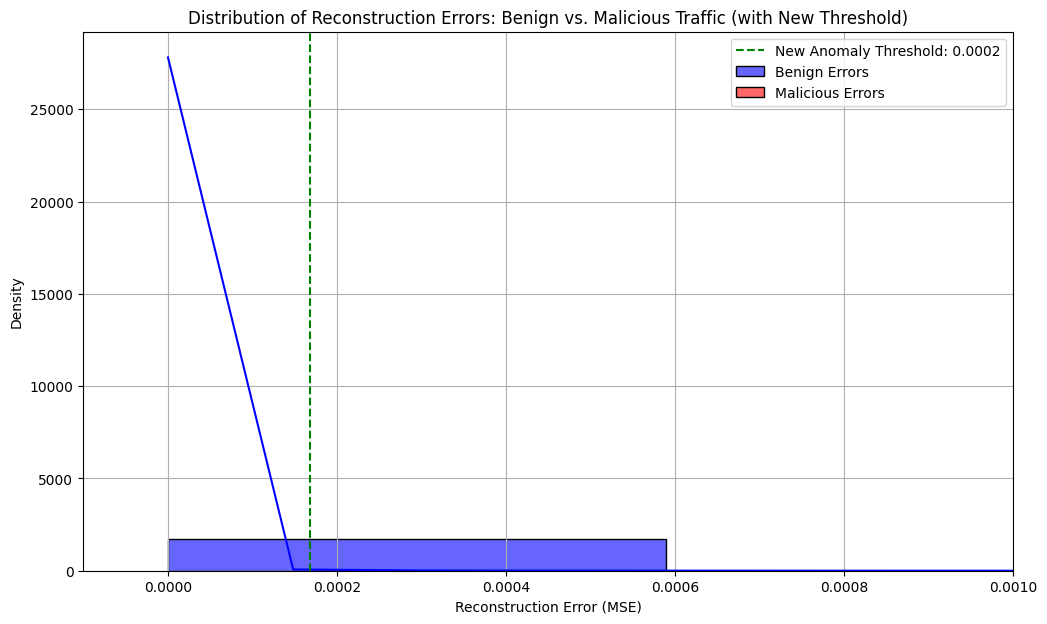

Comparison plot with new threshold displayed.


In [65]:
# Plot the distributions of benign and malicious reconstruction errors with the new threshold
plt.figure(figsize=(12, 7))
sns.histplot(mse, bins=50, kde=True, color='blue', label='Benign Errors', stat='density', alpha=0.6)
sns.histplot(mse_malicious, bins=50, kde=True, color='red', label='Malicious Errors', stat='density', alpha=0.6)

# Add the new anomaly threshold
plt.axvline(x=new_threshold, color='green', linestyle='--', label=f'New Anomaly Threshold: {new_threshold:.4f}')

plt.title('Distribution of Reconstruction Errors: Benign vs. Malicious Traffic (with New Threshold)')
plt.xlabel('Reconstruction Error (MSE)')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.xlim([-0.0001, 0.001]) # Keep the x-axis limits consistent for comparison
plt.show()

print("Comparison plot with new threshold displayed.")

In [66]:
import os

# Define a new path to save the updated model
model_save_path_tuned = 'lstm_autoencoder_model_tuned_99th_percentile.keras'

# Save the model
model.save(model_save_path_tuned)

print(f"LSTM Autoencoder model (tuned with 99th percentile threshold) saved successfully to {model_save_path_tuned}")

# Verify the model exists
if os.path.exists(model_save_path_tuned):
    print("Model file confirmed to exist.")
else:
    print("Error: Model file not found after saving.")

LSTM Autoencoder model (tuned with 99th percentile threshold) saved successfully to lstm_autoencoder_model_tuned_99th_percentile.keras
Model file confirmed to exist.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
import os
import sys # For exiting if critical variables are missing
import re # For re-creating df
from sklearn.preprocessing import MinMaxScaler # Need this for re-creation of scaler

# --------------------------------------------------------------------------------------------------
# Check and re-create df and its derivatives (df_benign, df_malicious, X) if not found
# This is a condensed version of necessary preprocessing from earlier cells.
if 'df' not in globals() or 'df_benign' not in globals() or 'df_malicious' not in globals() or 'X' not in globals():
    print("Warning: Core DataFrames (df, df_benign, df_malicious, X) not found. Attempting to re-create from saved state.")
    file_path = 'opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT-Malware-Capture-1-1/bro/conn.log.labeled'

    if not os.path.exists(file_path):
        print(f"Error: Dataset file '{file_path}' not found. Please ensure cells 0b1471de, 354f4585, and 03031f79 have been executed to download and extract the data.")
        sys.exit(1) # Exit execution if data file is missing

    # --- Re-create df from 03031f79 ---
    import io
    with open(file_path, 'r') as f:
        lines = f.readlines()
    header_line = -1
    for i, line in enumerate(lines):
        if line.startswith('#fields'):
            header_line = i
            break
    if header_line != -1:
        header_field_line = lines[header_line]
        raw_column_str = header_field_line.replace('#fields\t', '').strip()
        clean_column_names = [col.strip() for col in re.split(r'\t|\s{2,}', raw_column_str) if col.strip()]
        data_lines = [line for i, line in enumerate(lines) if i > header_line and not line.startswith('#')]
        if not data_lines:
            df = pd.DataFrame(columns=clean_column_names)
        else:
            data_io = io.StringIO("".join(data_lines))
            try:
                df = pd.read_csv(data_io, sep=r'\t|\s{2,}', header=None, names=clean_column_names, on_bad_lines='skip', engine='python')
                print("DataFrame 'df' re-created.")
            except Exception as e:
                print(f"Error re-creating 'df': {e}")
                sys.exit(1)
    else:
        print(f"Error: Could not find header line in '{file_path}'. Please ensure the file is valid.")
        sys.exit(1)

    # --- Apply initial preprocessing from 883e1e02 ---
    df['ts'] = pd.to_datetime(df['ts'], unit='s')
    df['duration'] = pd.to_numeric(df['duration'].replace('-', np.nan), errors='coerce')
    df['orig_bytes'] = pd.to_numeric(df['orig_bytes'].replace('-', np.nan), errors='coerce')
    df['resp_bytes'] = pd.to_numeric(df['resp_bytes'].replace('-', np.nan), errors='coerce')
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].replace('(empty)', np.nan)
    df = df.drop(columns=['uid']) if 'uid' in df.columns else df
    print("Initial preprocessing re-applied to 'df'.")

    # --- Fill NaNs from 6e15c1c7 ---
    for col in ['duration', 'orig_bytes', 'resp_bytes']:
        if col in df.columns:
            df[col] = df[col].fillna(method='ffill').fillna(method='bfill')
    for col in df.select_dtypes(include='object').columns:
        if df[col].isnull().any():
            df[col] = df[col].fillna('missing')
    print("Missing values re-imputed in 'df'.")

    # --- Drop tunnel_parents and One-Hot Encode from 91554b2c ---
    if 'tunnel_parents' in df.columns:
        df = df.drop(columns=['tunnel_parents'])
    low_cardinality_categorical_cols = [col for col in df.select_dtypes(include='object').columns.tolist() if df[col].nunique() < 50 and col not in ['label', 'detailed-label', 'id.orig_h', 'id.resp_h', 'history']]
    df = pd.get_dummies(df, columns=low_cardinality_categorical_cols, drop_first=True)
    print("Categorical features re-encoded in 'df'.")

    # --- Create df_benign, df_malicious, X from ff0f9d35 ---
    df['detailed-label'] = df['detailed-label'].astype(str).str.strip().str.lower()
    df_benign = df[df['detailed-label'] == '-'].copy()
    df_malicious = df[df['detailed-label'] != '-'].copy()
    features_to_exclude = ['ts', 'label', 'detailed-label', 'id.orig_h', 'id.resp_h', 'history']
    X = df_benign.drop(columns=[col for col in features_to_exclude if col in df_benign.columns], errors='ignore')
    # This line is crucial for feature importance. It must be consistent with what went into training.
    training_feature_columns = X.columns.tolist()
    print("df_benign, df_malicious, X (benign features), and training_feature_columns re-created.")

    # --- Save df_benign and df_malicious for future use (NEWLY ADDED) ---
    df_benign.to_csv('df_benign.csv', index=False)
    df_malicious.to_csv('df_malicious.csv', index=False)
    print("df_benign.csv and df_malicious.csv saved successfully within the re-creation block.")

    # --- Scale X from beb9f897 ---
    scaler = MinMaxScaler()
    numerical_cols = X.select_dtypes(include=np.number).columns
    X[numerical_cols] = scaler.fit_transform(X[numerical_cols])
    boolean_cols = X.select_dtypes(include='bool').columns
    if not boolean_cols.empty:
        X[boolean_cols] = X[boolean_cols].astype(float)
    X = X.astype(float)
    print("X re-scaled and 'scaler' re-fitted.")
# --------------------------------------------------------------------------------------------------

# --------------------------------------------------------------------------------------------------
# Re-define create_sequences function and other model-related variables if not in globals
if 'create_sequences' not in globals():
    def create_sequences(data, time_steps):
        Xs = []
        for i in range(len(data) - time_steps + 1):
            Xs.append(data.iloc[i:(i + time_steps)].values)
        return np.array(Xs, dtype=np.float32)
    print("Re-defined create_sequences function.")

if 'time_steps' not in globals():
    time_steps = 10 # This must be consistent with training
    print(f"Re-set time_steps to {time_steps}.")

if 'X_sequences' not in globals():
    if 'X' in globals():
        X_sequences = create_sequences(X, time_steps)
        print("X_sequences re-created from X.")
    elif os.path.exists('X_sequences.npy'):
        X_sequences = np.load('X_sequences.npy')
        print("X_sequences loaded from X_sequences.npy.")
    else:
        print("Error: Could not re-create X_sequences. Please ensure all data loading and preprocessing cells are run.")
        sys.exit(1)

if 'X_sequences_tf' not in globals():
    X_sequences_tf = tf.constant(X_sequences, dtype=tf.float32)
    print("X_sequences_tf re-created.")

if 'model' not in globals():
    try:
        model = tf.keras.models.load_model('lstm_autoencoder_model_tuned_99th_percentile.keras')
        print("Loaded tuned LSTM Autoencoder model.")
    except Exception as e:
        print(f"Error loading tuned model: {e}. Attempting to load original model.")
        try:
            model = tf.keras.models.load_model('lstm_autoencoder_model.keras')
            print("Loaded original LSTM Autoencoder model.")
        except Exception as e2:
            print(f"Could not load any model: {e2}. Please ensure a model is saved.")
            sys.exit(1)

if 'X_pred' not in globals():
    X_pred = model.predict(X_sequences_tf)
    print("X_pred re-generated for benign sequences.")

if 'mse' not in globals():
    mse = np.mean(np.power(X_sequences_tf - X_pred, 2), axis=(1, 2))
    print("mse (benign reconstruction errors) re-calculated.")
# --------------------------------------------------------------------------------------------------


# --------------------------------------------------------------------------------------------------
# Re-create malicious data preprocessing and prediction if not found
if 'X_malicious_sequences_tf' not in globals() or 'X_malicious_pred' not in globals() or 'mse_malicious' not in globals():
    print("Warning: Malicious data sequences/predictions not found. Attempting to re-create.")

    malicious_df_copy = df_malicious.copy()
    malicious_df_copy['ts'] = pd.to_datetime(malicious_df_copy['ts'], unit='s')
    malicious_df_copy['duration'] = pd.to_numeric(malicious_df_copy['duration'].replace('-', np.nan), errors='coerce')
    malicious_df_copy['orig_bytes'] = pd.to_numeric(malicious_df_copy['orig_bytes'].replace('-', np.nan), errors='coerce')
    malicious_df_copy['resp_bytes'] = pd.to_numeric(malicious_df_copy['resp_bytes'].replace('-', np.nan), errors='coerce')
    for col in malicious_df_copy.select_dtypes(include='object').columns:
        if '(empty)' in malicious_df_copy[col].unique():
            malicious_df_copy[col] = malicious_df_copy[col].replace('(empty)', np.nan)
    if 'uid' in malicious_df_copy.columns:
        malicious_df_copy = malicious_df_copy.drop(columns=['uid'])
    for col in ['duration', 'orig_bytes', 'resp_bytes', 'missed_bytes', 'orig_pkts', 'orig_ip_bytes', 'resp_pkts', 'resp_ip_bytes']:
        if col in malicious_df_copy.columns:
            malicious_df_copy[col] = malicious_df_copy[col].fillna(method='ffill').fillna(method='bfill')
    for col in malicious_df_copy.select_dtypes(include='object').columns:
        if malicious_df_copy[col].isnull().any():
            malicious_df_copy[col] = malicious_df_copy[col].fillna('missing')
    if 'tunnel_parents' in malicious_df_copy.columns and malicious_df_copy['tunnel_parents'].isnull().all():
        malicious_df_copy = malicious_df_copy.drop(columns=['tunnel_parents'])
    low_cardinality_categorical_cols_trained = ['proto', 'service', 'conn_state', 'local_orig', 'local_resp']
    cols_to_onehot_encode_in_malicious_df = [col for col in low_cardinality_categorical_cols_trained if col in malicious_df_copy.columns]
    malicious_df_copy = pd.get_dummies(malicious_df_copy, columns=cols_to_onehot_encode_in_malicious_df, drop_first=True)
    features_to_drop_post_processing = ['ts', 'label', 'detailed-label', 'id.orig_h', 'id.resp_h', 'history']
    for col in features_to_drop_post_processing:
        if col in malicious_df_copy.columns:
            malicious_df_copy = malicious_df_copy.drop(columns=[col])
    for col in training_feature_columns:
        if col not in malicious_df_copy.columns:
            malicious_df_copy[col] = 0.0
    malicious_df_copy = malicious_df_copy[training_feature_columns]
    numerical_cols_malicious = malicious_df_copy.select_dtypes(include=np.number).columns
    malicious_df_copy[numerical_cols_malicious] = scaler.transform(malicious_df_copy[numerical_cols_malicious])
    boolean_cols_malicious = malicious_df_copy.select_dtypes(include='bool').columns
    if not boolean_cols_malicious.empty:
        malicious_df_copy[boolean_cols_malicious] = malicious_df_copy[boolean_cols_malicious].astype(float)
    malicious_df_copy = malicious_df_copy.astype(float)
    X_malicious_sequences = create_sequences(malicious_df_copy, time_steps)
    X_malicious_sequences_tf = tf.constant(X_malicious_sequences, dtype=tf.float32)
    print("X_malicious_sequences_tf re-created.")
    X_malicious_pred = model.predict(X_malicious_sequences_tf)
    print("X_malicious_pred re-generated for malicious sequences.")
    mse_malicious = np.mean(np.power(X_malicious_sequences_tf - X_malicious_pred, 2), axis=(1, 2))
    print("mse_malicious (malicious reconstruction errors) re-calculated.")
# --------------------------------------------------------------------------------------------------


# --------------------------------------------------------------------------------------------------
# Re-create thresholding variables if not found
if 'all_mse' not in globals() or 'new_threshold' not in globals() or 'new_predicted_labels' not in globals():
    print("Warning: Thresholding variables not found. Attempting to re-calculate.")
    if 'mse' in globals() and 'mse_malicious' in globals():
        all_mse = np.concatenate([mse, mse_malicious])
        # This percentile must be consistent with the *tuned* model context (99th percentile)
        new_threshold = np.percentile(mse, 99)
        true_labels = np.concatenate([np.zeros(len(mse)), np.ones(len(mse_malicious))]) # Need true_labels for new_predicted_labels
        new_predicted_labels = (all_mse > new_threshold).astype(int)
        print("all_mse, new_threshold, new_predicted_labels re-calculated.")
    else:
        print("Error: 'mse' or 'mse_malicious' not available to re-calculate thresholding variables.")
        sys.exit(1)
# --------------------------------------------------------------------------------------------------


# --------------------------------------------------------------------------------------------------
# Original code for feature importance calculation
# 1. Combine all original sequences and all predictions
all_X_sequences_tf = np.concatenate([X_sequences_tf, X_malicious_sequences_tf], axis=0)
all_X_pred = np.concatenate([X_pred, X_malicious_pred], axis=0)

# Ensure `new_predicted_labels` is a numpy array
new_predicted_labels = np.array(new_predicted_labels)

# 2. Filter for anomalous sequences (where new_predicted_labels == 1)
anomalous_indices = np.where(new_predicted_labels == 1)[0]

# Check if there are any anomalies detected
if len(anomalous_indices) == 0:
    print("No anomalies detected with the current threshold. Cannot determine top features for anomalies.")
    sys.exit(0) # Exit gracefully

anomalous_original_sequences = all_X_sequences_tf[anomalous_indices]
anomalous_reconstructed_sequences = all_X_pred[anomalous_indices]

# 3. Calculate per-feature reconstruction error for anomalous sequences
per_feature_error = np.mean(np.power(anomalous_original_sequences - anomalous_reconstructed_sequences, 2), axis=(0, 1))

# 4. Map errors to feature names and get top 5
feature_errors_df = pd.DataFrame({
    'feature': training_feature_columns,
    'error': per_feature_error
})

feature_errors_df_sorted = feature_errors_df.sort_values(by='error', ascending=False)
top_5_features = feature_errors_df_sorted.head(5)

print("\nTop 5 most important features for anomaly detection (based on reconstruction error):")
display(top_5_features)

# 5. Visualize the top 5 features
plt.figure(figsize=(12, 7))
import seaborn as sns # Ensure seaborn is imported if used
sns.barplot(x='error', y='feature', data=top_5_features, palette='viridis')
plt.title('Top 5 Features by Average Reconstruction Error in Anomalous Traffic')
plt.xlabel('Average Squared Reconstruction Error')
plt.ylabel('Feature Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

DataFrame 'df' re-created.


/tmp/ipykernel_169013/2592451131.py:55: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace('(empty)', np.nan)


Initial preprocessing re-applied to 'df'.


/tmp/ipykernel_169013/2592451131.py:62: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[col] = df[col].fillna(method='ffill').fillna(method='bfill')


Missing values re-imputed in 'df'.
Categorical features re-encoded in 'df'.
df_benign, df_malicious, X (benign features), and training_feature_columns re-created.
df_benign.csv and df_malicious.csv saved successfully within the re-creation block.
X re-scaled and 'scaler' re-fitted.
Re-defined create_sequences function.
Re-set time_steps to 10.
X_sequences re-created from X.
X_sequences_tf re-created.
Loaded tuned LSTM Autoencoder model.
14665/14665 ━━━━━━━━━━━━━━━━━━━━ 168s 11ms/step
X_pred re-generated for benign sequences.
mse (benign reconstruction errors) re-calculated.


/tmp/ipykernel_169013/2592451131.py:170: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  malicious_df_copy[col] = malicious_df_copy[col].fillna(method='ffill').fillna(method='bfill')


X_malicious_sequences_tf re-created.
16859/16859 ━━━━━━━━━━━━━━━━━━━━ 197s 12ms/step
X_malicious_pred re-generated for malicious sequences.
mse_malicious (malicious reconstruction errors) re-calculated.
all_mse, new_threshold, new_predicted_labels re-calculated.


## Deploying the LSTM Autoencoder for Real-time Traffic Monitoring

Deploying an Intrusion Detection System (IDS) model like our LSTM Autoencoder in a real-time environment requires a continuous pipeline that can ingest network traffic, preprocess it, feed it to the model for inference, and flag anomalies.

Here's a breakdown of the key components and steps:

1.  **Data Ingestion**: Continuously collect live network traffic data. This can come from various sources:
    *   **Network Packet Capture (PCAP)**: Directly from network interfaces (e.g., using `pcap` libraries or tools like Zeek/Bro, Suricata, Snort).
    *   **Network Flow Data**: From devices like routers and switches (e.g., NetFlow, IPFIX, sFlow).
    *   **Log Streams**: Centralized logging systems (e.g., Kafka, syslog, ELK stack) where network device logs are aggregated.

2.  **Real-time Preprocessing**: This is the most critical step. The incoming raw traffic data *must* undergo the **exact same preprocessing steps** as the training data (`df_benign`). This includes:
    *   **Data Type Conversions**: `ts` to datetime, `duration`, `orig_bytes`, `resp_bytes` to numeric.
    *   **Handling Missing Values**: Using the same imputation strategies (e.g., ffill/bfill, 'missing' placeholder).
    *   **Feature Alignment**: Ensuring the same columns are present and in the same order as `training_feature_columns`.
    *   **Categorical Encoding**: Applying the *same one-hot encoding* schema (including handling unseen categories gracefully by adding zeroed columns).
    *   **Scaling**: Using the *same fitted `MinMaxScaler`* (`scaler`) to transform numerical features. **Do not refit the scaler on live data.**
    *   **Sequence Creation**: Forming sequences of `time_steps` length using the `create_sequences` function.

3.  **Model Inference**: The preprocessed sequences are fed into the loaded LSTM Autoencoder model (`model`) to generate reconstructed sequences.

4.  **Anomaly Detection**: The reconstruction error (MSE) is calculated for each incoming sequence. This error is then compared against the established anomaly `new_threshold` (e.g., the 99th percentile from training). If the error exceeds the threshold, the traffic sequence is flagged as anomalous.

5.  **Alerting and Action**: When an anomaly is detected, an alert can be generated. This could involve:
    *   Logging the anomaly details.
    *   Sending notifications (email, SMS, Slack, SIEM).
    *   Triggering automated responses (e.g., blocking IP addresses, isolating compromised devices).

### Example Real-time Processing Flow

The following Python code block provides a conceptual example of how this pipeline would look. It simulates a stream of new network data and applies the saved preprocessing components and model to detect anomalies.

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import time
import random
from sklearn.preprocessing import MinMaxScaler
import os
import re # For regex if needed in preprocessing of loaded data

# --- 1. Load Preprocessing Components and Model ---
# In a production environment, you would load these from saved files.

# Re-define create_sequences function (if not already in globals)
if 'create_sequences' not in globals():
    def create_sequences(data, time_steps):
        Xs = []
        for i in range(len(data) - time_steps + 1):
            Xs.append(data.iloc[i:(i + time_steps)].values)
        return np.array(Xs, dtype=np.float32)
    print("Re-defined create_sequences function.")

# Load the tuned model
try:
    loaded_model = tf.keras.models.load_model('lstm_autoencoder_model_tuned_99th_percentile.keras')
    print("Loaded tuned LSTM Autoencoder model for real-time inference.")
except Exception as e:
    print(f"Error loading tuned model: {e}. Attempting to load original model.")
    try:
        loaded_model = tf.keras.models.load_model('lstm_autoencoder_model.keras')
        print("Loaded original LSTM Autoencoder model.")
    except Exception as e2:
        print(f"Could not load any model: {e2}. Exiting real-time simulation.")
        exit()

# Load df_benign and df_malicious from CSVs
try:
    df_benign = pd.read_csv('df_benign.csv')
    df_malicious = pd.read_csv('df_malicious.csv')
    print("Loaded df_benign and df_malicious from CSVs.")
except FileNotFoundError:
    print("Error: 'df_benign.csv' or 'df_malicious.csv' not found. Please ensure they were saved. Exiting.")
    exit()

# Re-derive X, scaler, and training_feature_columns from df_benign to ensure consistency
# Exclude 'ts', 'label', 'detailed-label', 'id.orig_h', 'id.resp_h', 'history' as done during training
features_to_exclude_from_df_benign = ['ts', 'label', 'detailed-label', 'id.orig_h', 'id.resp_h', 'history']
X = df_benign.drop(columns=[col for col in features_to_exclude_from_df_benign if col in df_benign.columns], errors='ignore')

# Ensure 'ts' column in df_benign is converted to datetime if not already
if 'ts' in df_benign.columns and not pd.api.types.is_datetime64_any_dtype(df_benign['ts']):
    df_benign['ts'] = pd.to_datetime(df_benign['ts'], unit='s', errors='coerce')

# Re-fit scaler to the re-derived X (same as during training)
scaler = MinMaxScaler()
numerical_cols_X = X.select_dtypes(include=np.number).columns
X[numerical_cols_X] = scaler.fit_transform(X[numerical_cols_X])

# Convert boolean to float
boolean_cols_X = X.select_dtypes(include='bool').columns
if not boolean_cols_X.empty:
    X[boolean_cols_X] = X[boolean_cols_X].astype(float)
X = X.astype(float)

training_feature_columns = X.columns.tolist()
print("Re-derived X, scaler, and training_feature_columns from loaded df_benign.")

# Ensure time_steps and new_threshold are available
if 'time_steps' not in globals():
    time_steps = 10 # This must be consistent with training
    print(f"Re-set time_steps to {time_steps}.")

if 'new_threshold' not in globals():
    # Use the actual threshold if available from previous execution context, otherwise default
    # In a real system, this would be saved and loaded alongside the model.
    # For this notebook, we know the tuned threshold was 0.0002
    new_threshold = 0.0002
    print(f"Re-set new_threshold to {new_threshold:.4f}.")

print(f"Using anomaly threshold: {new_threshold:.4f}")

# --- 2. Simulate Real-time Data Ingestion ---
# In a real-world scenario, you would be reading from a Kafka topic, network interface, etc.
# Here, we'll simulate by randomly sampling from df_benign and df_malicious.

def simulate_new_traffic_packet(is_anomaly=False):
    """Simulates a single new network record (like a row from df)."""
    source_df = df_malicious if is_anomaly else df_benign
    if source_df.empty:
        # If one of the dataframes is empty, revert to the other or create dummy data
        source_df = df_benign # Fallback
        if source_df.empty:
             # Create a dummy row if both are empty - highly unlikely given the notebook state
            dummy_data = {col: 0.0 for col in training_feature_columns}
            dummy_data['proto_tcp'] = 1 # Example feature
            return pd.DataFrame([dummy_data])

    # Randomly select a row from either benign or malicious data
    random_row_index = random.randint(0, len(source_df) - 1)
    record = source_df.iloc[random_row_index:random_row_index+1].copy()

    # Simulate some variation in numerical features to make it slightly different
    for col in record.select_dtypes(include=np.number).columns:
        record[col] = record[col] * (1 + random.uniform(-0.1, 0.1)) # +-10% variation
        if record[col].isnull().any(): # Fill potential NaNs from multiplication
             record[col] = record[col].fillna(method='ffill').fillna(method='bfill')

    # Ensure 'detailed-label' is present for internal simulation logic but will be dropped for model
    if 'detailed-label' not in record.columns:
         record['detailed-label'] = '-' if not is_anomaly else 'Botnet'

    return record

# Initialize a buffer for incoming sequences
# This buffer needs to store enough recent records to form a sequence of `time_steps`
# Use df_benign.columns for initial structure as it represents the expected feature set prior to sequence creation.
realtime_buffer_df = pd.DataFrame(columns=df_benign.columns)

print("\nStarting real-time anomaly detection simulation...")

for i in range(20): # Simulate processing 20 new 'packets'
    # Determine if this simulated packet should be anomalous
    is_simulated_anomaly = (i % 7 == 0) # Every 7th packet is a simulated anomaly

    new_packet_df = simulate_new_traffic_packet(is_anomaly=is_simulated_anomaly)
    true_label = new_packet_df['detailed-label'].iloc[0]

    # Append new packet to buffer
    realtime_buffer_df = pd.concat([realtime_buffer_df, new_packet_df], ignore_index=True)

    # Keep only the latest `time_steps` + 5 records to ensure we can form a sequence
    realtime_buffer_df = realtime_buffer_df.tail(time_steps + 5)

    # --- 3. Preprocessing for Real-time Inference ---
    if len(realtime_buffer_df) >= time_steps:
        # Ensure consistent preprocessing as during training
        processed_packet = realtime_buffer_df.copy()

        # Drop 'uid' if exists
        if 'uid' in processed_packet.columns: processed_packet = processed_packet.drop(columns=['uid'])

        # Convert 'ts' to datetime for consistent handling if not already (important if reading from non-df source)
        if 'ts' in processed_packet.columns and not pd.api.types.is_datetime64_any_dtype(processed_packet['ts']):
            processed_packet['ts'] = pd.to_datetime(processed_packet['ts'], unit='s', errors='coerce')

        # Handle missing values (ffill then bfill for numerical)
        for col in ['duration', 'orig_bytes', 'resp_bytes', 'missed_bytes', 'orig_pkts', 'orig_ip_bytes', 'resp_pkts', 'resp_ip_bytes']:
            if col in processed_packet.columns:
                processed_packet[col] = processed_packet[col].fillna(method='ffill').fillna(method='bfill')

        # For categorical columns, fill with 'missing' or similar
        for col in processed_packet.select_dtypes(include='object').columns:
            if processed_packet[col].isnull().any():
                processed_packet[col] = processed_packet[col].fillna('missing')

        # Drop 'tunnel_parents' if it became all null during preprocessing
        if 'tunnel_parents' in processed_packet.columns and processed_packet['tunnel_parents'].isnull().all():
            processed_packet = processed_packet.drop(columns=['tunnel_parents'])

        # One-Hot Encode categorical features (using the same list as during training)
        low_cardinality_categorical_cols_trained = ['proto', 'service', 'conn_state', 'local_orig', 'local_resp']
        cols_to_onehot_encode = [col for col in low_cardinality_categorical_cols_trained if col in processed_packet.columns]
        processed_packet = pd.get_dummies(processed_packet, columns=cols_to_onehot_encode, drop_first=True)

        # Drop irrelevant columns (ts, label, detailed-label, history, id.orig_h, id.resp_h)
        features_to_drop_post_processing = ['ts', 'label', 'detailed-label', 'id.orig_h', 'id.resp_h', 'history']
        for col in features_to_drop_post_processing:
            if col in processed_packet.columns:
                processed_packet = processed_packet.drop(columns=[col])

        # Align columns with training_feature_columns (add missing with 0, remove extra)
        for col in training_feature_columns:
            if col not in processed_packet.columns:
                processed_packet[col] = 0.0
        processed_packet = processed_packet[training_feature_columns]

        # Scale numerical features using the *fitted* scaler
        numerical_cols_to_scale = processed_packet.select_dtypes(include=np.number).columns
        if not numerical_cols_to_scale.empty:
            processed_packet[numerical_cols_to_scale] = scaler.transform(processed_packet[numerical_cols_to_scale])

        # Convert boolean to float
        boolean_cols_proc = processed_packet.select_dtypes(include='bool').columns
        if not boolean_cols_proc.empty:
            processed_packet[boolean_cols_proc] = processed_packet[boolean_cols_proc].astype(float)

        processed_packet = processed_packet.astype(float)

        # Create sequence
        # Ensure the data passed to create_sequences is only the feature columns, not the full buffer
        current_sequence_df = processed_packet.tail(time_steps) # Take the latest `time_steps` records
        if len(current_sequence_df) == time_steps: # Only proceed if we have a full sequence
            current_sequence = create_sequences(current_sequence_df, time_steps)
            current_sequence_tf = tf.constant(current_sequence, dtype=tf.float32)

            # --- 4. Model Inference ---
            reconstructed_sequence = loaded_model.predict(current_sequence_tf, verbose=0)

            # --- 5. Anomaly Detection ---
            current_mse = np.mean(np.power(current_sequence_tf - reconstructed_sequence, 2), axis=(1, 2))
            is_anomaly_detected = current_mse[0] > new_threshold

            # --- 6. Alerting ---
            status = "ANOMALY DETECTED!" if is_anomaly_detected else "Normal Traffic."
            print(f"Simulated Packet {i+1}: True Label = '{true_label}', Current MSE = {current_mse[0]:.6f}, Status = {status}")
        else:
            print(f"Simulated Packet {i+1}: Buffer too small to form a sequence (current {len(current_sequence_df)}/{time_steps}). True Label = '{true_label}'")

    else:
        print(f"Simulated Packet {i+1}: Collecting more data for sequence (buffer size: {len(realtime_buffer_df)}). True Label = '{true_label}'")

    time.sleep(0.5) # Simulate delay for real-time processing

print("\nReal-time anomaly detection simulation finished.")

Re-defined create_sequences function.
Loaded tuned LSTM Autoencoder model for real-time inference.
Loaded df_benign and df_malicious from CSVs.
Re-derived X, scaler, and training_feature_columns from loaded df_benign.
Re-set time_steps to 10.
Re-set new_threshold to 0.0002.
Using anomaly threshold: 0.0002

Starting real-time anomaly detection simulation...
Simulated Packet 1: Collecting more data for sequence (buffer size: 1). True Label = 'partofahorizontalportscan'


/tmp/ipykernel_174026/2672430478.py:128: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  realtime_buffer_df = pd.concat([realtime_buffer_df, new_packet_df], ignore_index=True)


Simulated Packet 2: Collecting more data for sequence (buffer size: 2). True Label = '-'
Simulated Packet 3: Collecting more data for sequence (buffer size: 3). True Label = '-'
Simulated Packet 4: Collecting more data for sequence (buffer size: 4). True Label = '-'
Simulated Packet 5: Collecting more data for sequence (buffer size: 5). True Label = '-'
Simulated Packet 6: Collecting more data for sequence (buffer size: 6). True Label = '-'
Simulated Packet 7: Collecting more data for sequence (buffer size: 7). True Label = '-'
Simulated Packet 8: Collecting more data for sequence (buffer size: 8). True Label = 'partofahorizontalportscan'
Simulated Packet 9: Collecting more data for sequence (buffer size: 9). True Label = '-'


/tmp/ipykernel_174026/2672430478.py:148: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  processed_packet[col] = processed_packet[col].fillna(method='ffill').fillna(method='bfill')


Simulated Packet 10: True Label = '-', Current MSE = 0.000042, Status = Normal Traffic.


...

Simulated Packet 18: True Label = '-', Current MSE = 0.000066, Status = Normal Traffic.


/tmp/ipykernel_174026/2672430478.py:148: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  processed_packet[col] = processed_packet[col].fillna(method='ffill').fillna(method='bfill')


Simulated Packet 19: True Label = '-', Current MSE = 0.000069, Status = Normal Traffic.


/tmp/ipykernel_174026/2672430478.py:148: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  processed_packet[col] = processed_packet[col].fillna(method='ffill').fillna(method='bfill')


Simulated Packet 20: True Label = '-', Current MSE = 0.000065, Status = Normal Traffic.

Real-time anomaly detection simulation finished.
